# DIA-NN Validation Toolkit

This notebook demonstrates how to validate DIA-NN search results by visualizing:
- **Mirror plots**: Compare observed vs predicted spectra
- **Fragment coverage**: Which peptide bonds are supported by observed ions
- **Batch coverage analysis**: Calculate coverage across all precursors

Key feature: **Multi-file support** - load and analyze precursors across multiple RAW files simultaneously.

In [1]:
%reload_ext autoreload
%autoreload 2

from IPython.display import Image
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)



## 1. Load Data

Load DIA-NN results and multiple RAW files. The `load_diann_data` function:
- Reads the DIA-NN report (parquet format)
- Loads multiple RAW files into a dictionary keyed by filename
- Generates a spectral library with predicted fragment intensities using PeptDeep

In [2]:
from src.diann_io import load_diann_data
from src.slicer import SpectrumSlicer

precursor_df, speclib_base, spectral_library_flat, dia_data = load_diann_data(
    diann_report_path="/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20251021_Neat_Plasma_DDA_96_fractions/03_DIANN_output/report.parquet",
    raw_file_path=[
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_01_G1.raw",
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_02_G2.raw",
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_03_G3.raw",
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_04_G4.raw",
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_05_G5.raw",
        "/fs/pool/pool-mann-projects/Kathrin/Projects/08_Deep_plasma_library/20250929_Quant_clean_neat/02_raw_data/20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_06_G6.raw",
    ],
    model_device="cpu",
)

/fs/gpfs41/lv07/fileset03/home/b_mann/lebedev/micromamba/envs/dia_validate/lib/python3.12/site-packages/alphabase/tools/data_downloader.py:4: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi
29it [00:22,  1.29it/s]


2025-12-10 14:35:49> Determining DIA cycle
2025-12-10 14:35:49> Found cycle with start 0.00 min and length 301.


29it [00:22,  1.26it/s]


2025-12-10 14:36:15> Determining DIA cycle
2025-12-10 14:36:15> Found cycle with start 0.00 min and length 301.


29it [00:22,  1.32it/s]


...

29it [00:22,  1.31it/s]


2025-12-10 14:37:30> Determining DIA cycle
2025-12-10 14:37:30> Found cycle with start 0.00 min and length 301.


29it [00:21,  1.34it/s]


2025-12-10 14:37:54> Determining DIA cycle
2025-12-10 14:37:54> Found cycle with start 0.00 min and length 301.
2025-12-10 14:38:11> Using multiprocessing with 8 processes ...
2025-12-10 14:38:12> Predicting rt,mobility,ms2 ...


100%|██████████| 24/24 [01:14<00:00,  3.10s/it]


In [3]:
# When multiple RAW files are loaded, dia_data is a dictionary
print(f"Loaded {len(dia_data)} RAW files:")
for name in dia_data.keys():
    print(f"  - {name}")

print(f"\nTotal precursors: {len(precursor_df):,}")
print(f"Unique RAW files in precursor_df: {precursor_df['raw_name'].nunique()}")

Loaded 6 RAW files:
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_01_G1
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_02_G2
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_03_G3
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_04_G4
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_05_G5
  - 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_06_G6

Total precursors: 209,782
Unique RAW files in precursor_df: 6


## 2. Initialize the Slicer

The `SpectrumSlicer` provides a unified interface to extract spectrum slices for any precursor, automatically routing to the correct RAW file based on `raw_name`.

In [4]:
slicer = SpectrumSlicer(spectral_library_flat, precursor_df, dia_data)

Converting RT values to DIA cycle frame indices...


## 3. Select a Precursor

Choose a precursor to visualize. With multi-file support, you must specify both:
- `selected_hash`: The precursor identifier
- `raw_name`: Which RAW file contains the observation

In [8]:
precursor_df

,raw_name,sequence,charge,rt,rt_start,rt_stop,mobility,proteins,uniprot_ids,genes,fdr,intensity,precursor_intensity,precursor_id,gene_intensity,fdr1_search1,fdr2_search1,fdr1_search2,fdr2_search2,mods,mod_sites,nAA,rt_norm,precursor_mz,ccs,instrument,nce,mod_seq_hash,mod_seq_charge_hash,frame_start,frame_stop,scan_start,scan_stop
0,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_05_G5,YYWSLWR,2,1068.781128,1060.411011,1074.344727,0.0,alphanovo_peptide_17503,alphanovo_peptide_17503,,0.003049,6.715314e+06,6.715313e+06,YYWSLWR2,0.000,0.001582,0.003957,0.001232,0.001230,NaN,NaN,7,0.833745,537.263802,0.0,Orbitrap,25.0,11006968272100835268,11006968272100835270,114079.0,115584.0,0,0
1,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_06_G6,YYWSLWR,2,1071.726318,1063.340210,1077.291626,0.0,alphanovo_peptide_17503,alphanovo_peptide_17503,,0.002005,6.236691e+06,6.236690e+06,YYWSLWR2,0.000,0.001582,0.003957,0.001232,0.001230,NaN,NaN,7,0.835513,537.263802,0.0,Orbitrap,25.0,11006968272100835268,11006968272100835270,114380.0,115885.0,0,0
2,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_01_G1,YYWTRVW,2,1004.785095,999.218994,1013.116821,0.0,alphanovo_peptide_53267,alphanovo_peptide_53267,,0.001475,3.566127e+04,3.566127e+04,YYWTRVW2,0.000,0.001475,0.003322,0.001170,0.001230,NaN,NaN,7,0.781126,537.263802,0.0,Orbitrap,25.0,7360489031735483020,7360489031735483022,107457.0,108962.0,0,0
3,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_02_G2,YYWTRVW,2,1001.734070,993.398682,1007.277832,0.0,alphanovo_peptide_53267,alphanovo_peptide_53267,,0.001769,4.638477e+04,4.638477e+04,YYWTRVW2,0.000,0.001475,0.003322,0.001170,0.001230,NaN,NaN,7,0.776467,537.263802,0.0,Orbitrap,25.0,7360489031735483020,7360489031735483022,106855.0,108360.0,0,0
4,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_03_G3,YYWTRVW,2,1005.162048,999.598877,1010.707947,0.0,alphanovo_peptide_53267,alphanovo_peptide_53267,,0.002029,4.166271e+04,4.166271e+04,YYWTRVW2,0.000,0.001475,0.003322,0.001170,0.001230,NaN,NaN,7,0.786517,537.263802,0.0,Orbitrap,25.0,7360489031735483020,7360489031735483022,107457.0,108661.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209777,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_02_G2,FSSGHVGGTLGQFYQEVLWGSPAASDDGRR,4,1140.252075,1126.297852,1148.617188,0.0,alphanovo_peptide_3050,alphanovo_peptide_3050,,0.000676,1.456501e+06,1.456501e+06,FSSGHVGGTLGQFYQEVLWGSPAASDDGRR4,0.000,0.000676,0.001484,0.000010,0.000275,NaN,NaN,30,0.883836,796.132607,0.0,Orbitrap,25.0,8144795976798002632,8144795976798002636,121002.0,123410.0,0,0
209778,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_03_G3,HGMTLTSMYQNSNIQIHHYPNGIVTVNCAR,4,876.117676,867.817871,881.681824,0.0,Q15582,Q15582,TGFBI,0.005800,1.707368e+06,1.720560e+05,HGMTLTSMYQNSNIQIHHYPNGIVTVNC(UniMod:4)AR4,1707368.125,0.001190,0.000344,0.001979,0.000275,Carbamidomethyl@C,28,30,0.685543,864.914410,0.0,Orbitrap,25.0,10280555426435806579,10280555426435806583,93009.0,94514.0,0,0
209779,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_04_G4,HGMTLTSMYQNSNIQIHHYPNGIVTVNCAR,4,875.928650,870.372742,884.277771,0.0,Q15582,Q15582,TGFBI,0.001291,1.809279e+06,1.586226e+05,HGMTLTSMYQNSNIQIHHYPNGIVTVNC(UniMod:4)AR4,1809278.625,0.001190,0.000344,0.001979,0.000275,Carbamidomethyl@C,28,30,0.681264,864.914410,0.0,Orbitrap,25.0,10280555426435806579,10280555426435806583,93310.0,94815.0,0,0
209780,20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_04_G4,FSSGHVGGTLGQFYQEVLWGSPAASDDGRR,4,1143.548950,1135.169312,1151.928467,0.0,alphanovo_peptide_3050,alphanovo_peptide_3050,,0.002476,1.620774e+06,1.620774e+06,FSSGHVGGTLGQFYQEVLWGSPAASDDGRR4,0.000,0.000676,0.001484,0.000010,0.000275,NaN,NaN,30,0.889409,796.132607,0.0,Orbitrap,25.0,8144795976798002632,8144795976798002636,121905.0,123711.0,0,0


In [ ]:
idx = 209780
selected_hash = precursor_df["mod_seq_charge_hash"].iloc[idx]
raw_name = precursor_df["raw_name"].iloc[idx]

print(f"Selected precursor: {selected_hash}")
print(f"From RAW file: {raw_name}")

Selected precursor: 8144795976798002636
From RAW file: 20250908_OA3_Eno03_SA_60SPD_KaKo_Sample_Plasma_Neat_Clean_04_G4


## 4. Visualize: Mirror Plot

The mirror plot shows:
- **Top**: Observed spectrum (colored by RT scan)
- **Bottom**: Predicted spectrum (inverted)
- **Right**: XIC profile across RT scans
- **Below**: Per-fragment correlation coefficients

In [10]:
from src.mirror_plotting import mirror_with_xic_and_corrs_for_hash

mirror_with_xic_and_corrs_for_hash(
    slicer,
    selected_hash,
    raw_name=raw_name,
    width=600,
    height=300,
)

alt.HConcatChart(...)

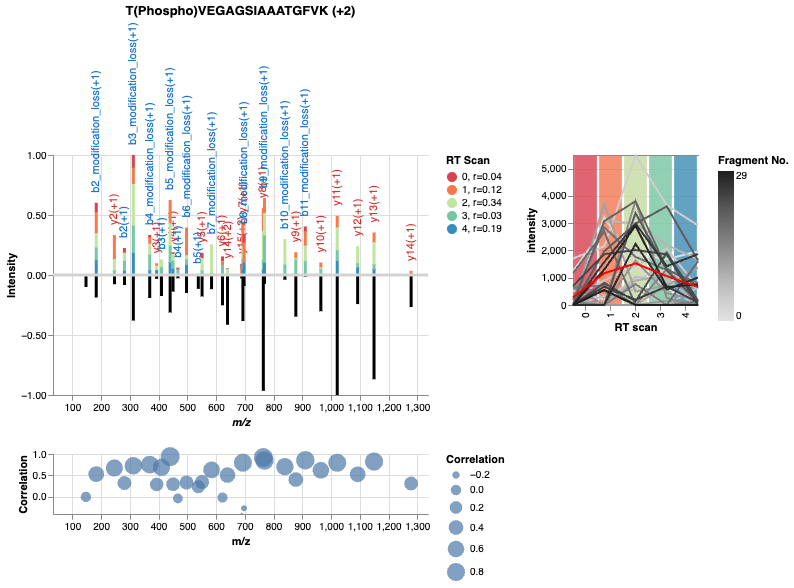

In [2]:
Image(filename="../misc/mirror_diann.png")

## 5. Visualize: Fragment Coverage

The fragment coverage plot shows which peptide bonds are supported by observed fragment ions:
- **b-ions** (blue): N-terminal fragments, shown below the sequence
- **y-ions** (red): C-terminal fragments, shown above the sequence

Coverage percentage indicates what fraction of peptide bonds have at least one supporting ion.

<Axes: title={'center': 'Coverage: 62.1%'}>

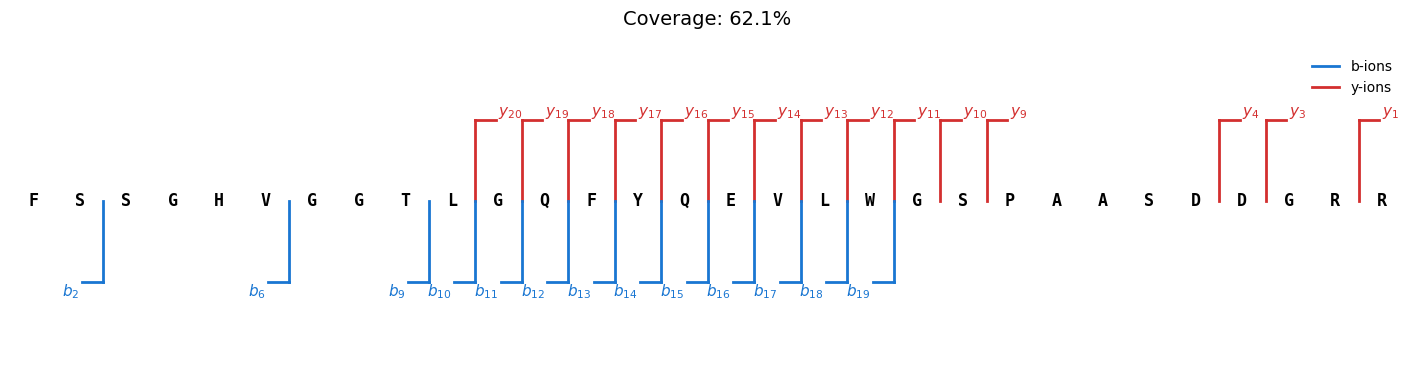

In [11]:
from src.fragment_coverage import plot_fragment_coverage_for_hash

plot_fragment_coverage_for_hash(
    slicer,
    selected_hash,
    raw_name=raw_name,
)

## 6. Batch Coverage Calculation

Calculate fragment coverage for all precursors to identify low-quality identifications. This is useful for:
- Quality control of search results
- Filtering precursors with poor spectral support
- Comparing coverage between different peptide sources

In [ ]:
from tqdm.auto import tqdm
from src.fragment_coverage import calculate_coverage_with_slicer

precursor_df["sequence_coverage"] = [
    calculate_coverage_with_slicer(slicer, hash_val, raw_name=rn)
    for hash_val, rn in tqdm(
        zip(precursor_df["mod_seq_charge_hash"], precursor_df["raw_name"]),
        total=len(precursor_df),
        desc="Calculating coverage",
    )
]

In [ ]:
import matplotlib.pyplot as plt

print("Coverage statistics:")
print(f"  Mean:   {precursor_df['sequence_coverage'].mean():.1%}")
print(f"  Median: {precursor_df['sequence_coverage'].median():.1%}")
print(f"  >80%:   {(precursor_df['sequence_coverage'] > 0.8).sum():,} precursors")

fig, ax = plt.subplots(figsize=(8, 4))
precursor_df["sequence_coverage"].hist(bins=50, ax=ax, edgecolor="white")
ax.set_xlabel("Sequence Coverage")
ax.set_ylabel("Count")
ax.set_title("Distribution of Fragment Coverage")
ax.axvline(0.8, color="red", linestyle="--", label="80% threshold")
ax.legend()
plt.tight_layout()

## 7. Filter by Coverage

Use coverage to find high-confidence long peptides or investigate low-coverage hits:

In [ ]:
# High-confidence long peptides
high_quality_long = precursor_df[
    (precursor_df["nAA"] > 20) & 
    (precursor_df["sequence_coverage"] > 0.8)
]
print(f"Long peptides (>20 AA) with >80% coverage: {len(high_quality_long):,}")
high_quality_long[["sequence", "charge", "raw_name", "sequence_coverage"]].head(10)

In [ ]:
# Investigate a low-coverage hit
low_coverage = precursor_df[precursor_df["sequence_coverage"] < 0.3].iloc[0]
print(f"Low coverage example: {low_coverage['sequence']} ({low_coverage['sequence_coverage']:.1%})")

plot_fragment_coverage_for_hash(
    slicer,
    low_coverage["mod_seq_charge_hash"],
    raw_name=low_coverage["raw_name"],
    title="Low coverage example",
)